In [20]:
#if your cell keeps throwing import errors, run the following pip installs to get the correct libraries in place.
# uncomment if needed.
# !pip install cartopy
# !pip install cdsapi
# !pip install xarray
# !pip install matplotlib

import xarray as xr
import matplotlib.pyplot as plt
import os
import cartopy
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import matplotlib as mpl
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets
from IPython.display import display
import earthkit.data as ekd
import earthkit.plots as ekp
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from plotly.subplots import make_subplots

product_parameters ={
    "variable"            : ["precipitation"],
    'delivery_start'      : pd.Timestamp('2026-01-01'), # start date of *this* delivery
    'delivery_end'        : pd.Timestamp('2026-06-01'),
    'collection_start'    : pd.Timestamp('2002-01-01'), # start date of the *whole* dataset
    'collection_end'      : pd.Timestamp('2026-06-01'),
}

datadir = '../../../datasets/GIRAFE/'
frequency = "monthly"


### Check that all expected dates are present

In [21]:


# now a bit of manual work. copy paste an example path for one of the downloaded files here.
# then replace the string bits corresponding to the collection (satellite, instrument, version) and the date (YYYYMM) with the appropriate variables.
# for date in dates:
#     YYYYMM = date.strftime('%Y%m')
#     fname = f'http://wdc.dlr.de/C3S_312b_Lot2/O3/TC/{satellite}/{instrument}/ALG/{version}/L3_MONTHLY/{YYYYMM[:4]}/{YYYYMM}-C3S-L3_OZONE-O3_PRODUCTS-{instrument}-{satellite}-ALG-MONTHLY-{version}.nc'
# we will then test if all expected dates are present.

# these are the expected dates based on the collection start and end dates and the temporal resolution
collection_start = product_parameters['collection_start']
collection_end = product_parameters['collection_end']
if frequency == 'monthly': # month start frequency
    temporal_resolution = 'MS'
dates = pd.date_range(start=collection_start, end=collection_end, freq=temporal_resolution) # MS: month start frequency
dates_YYYYMM = dates.strftime("%Y%m")

# read the manifest file into a dataframe and extract the date information from the file paths
dir_data = os.path.join(datadir, frequency)
files = []
for root, dirs, filenames in os.walk(dir_data):
    for filename in filenames:
        # print(os.path.join(root, filename))
        files.append(os.path.join(root, filename))
        # files.append(filename)

# print(files)
df = pd.DataFrame(files, columns=["file_path"])
# print(df.to_markdown())
# raise SystemExit
df["file_date"] = df["file_path"].str.extract(r'PREmm(\d{6})', expand=False) # the '6' assumes date is in YYYYMM format. Adjust if different.

file_dates = set(df["file_date"].dropna())
dates_set = set(dates_YYYYMM)

missing_dates = list(dates_set - file_dates)
existing_dates = list(dates_set & file_dates)

if len(missing_dates) == 0:
    print("All expected dates were downloaded from the CDS.")
else:
    print(f'There are {len(existing_dates)} Existing dates:', existing_dates)
    print(f'There are {len(missing_dates)} Missing dates:', missing_dates)


All expected dates were downloaded from the CDS.


### Check metadata

In [4]:
fname = df["file_path"].iloc[-1] # last file of the list of existing files, for example.
print(fname)
# nc = xr.open_dataset(fname)
# print(nc.info())
ds = ekd.from_source("file", fname).to_fieldlist()
print(ds.ls())
print(ekd.from_source("file", fname).to_xarray().info())

../../../datasets/GIRAFE/monthly/2019/PREmm20191101000000120IMPGS01GL.nc
           variable level       valid_datetime units
0     precipitation  None  2019-11-01T00:00:00    mm
1  num_obs_fraction  None  2019-11-01T00:00:00     1
2      num_obs_rate  None  2019-11-01T00:00:00     1
3          num_days  None  2019-11-01T00:00:00     1
4      quality_flag  None  2019-11-01T00:00:00  None
5     num_days_snow  None  2019-11-01T00:00:00     1
xarray.Dataset {
dimensions:
	time = 1 ;
	nv = 2 ;
	lat = 180 ;
	lon = 360 ;

variables:
	datetime64[ns] time(time) ;
		time:long_name = Product dataset time given as seconds since 2000-01-01T00:00:00 ;
		time:standard_name = time ;
		time:axis = T ;
		time:bounds = time_bnds ;
	datetime64[ns] time_bnds(time, nv) ;
		time_bnds:long_name = Time cell boundaries ;
		time_bnds:comment = Contains the start and end times for the time period that the data represent. ;
	float64 lat(lat) ;
		lat:units = degrees_north ;
		lat:long_name = Latitude ;
		lat:stand

### Check one of the fields of the main variable

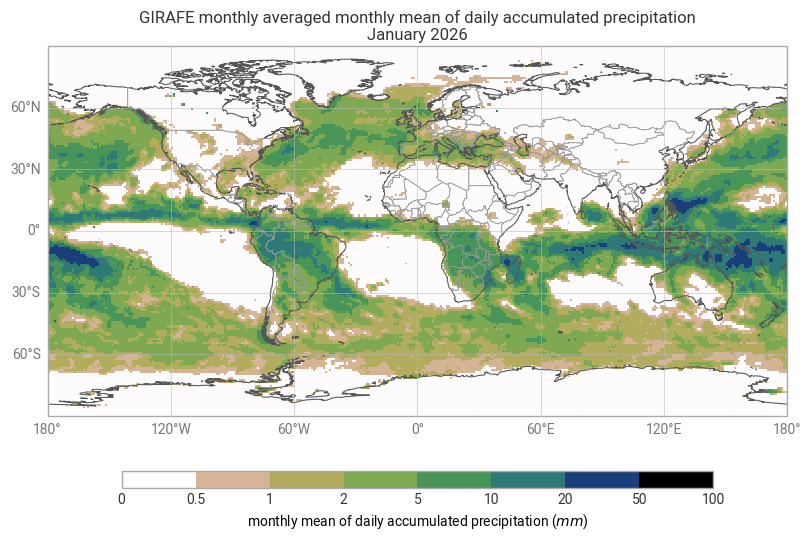

In [5]:
fname = df.loc[df["file_date"] == "202601", "file_path"].iloc[0] # get the file path for a specific date.

# nc = xr.open_dataset(fname)
# print(nc.info())
ds = ekd.from_source("file", fname).to_fieldlist()


style=ekp.styles.Style(
    colors="gist_earth_r",
    levels=[0,0.5,1,2,5,10,20,50,100],
    ticks=[0,0.5,1,2,5,10,20,50,100],
)

chart = ekp.Map()
# chart.contourf(ds[0],style=style)  
chart.pcolormesh(ds[0],style=style)

# Add a title with metadata formatting
chart.title("GIRAFE monthly averaged {variable_name}\n{time:%B %Y}")

# Add map decorations
chart.coastlines()
chart.borders()
chart.gridlines()

# Add a legend
chart.legend(label="{variable_name} ({units})") 
chart.show()

### Check values of main fields within the dataset
For monthly datasets, one plot per month per variable is checked.

For daily datasets, at least the file for day 1 of each month shall be checked.

In [6]:

# ------------------------------------------------------------
# Variables
# ------------------------------------------------------------
delivery_dates = pd.date_range(product_parameters['delivery_start'], product_parameters['delivery_end'], freq='MS') # MS: month start frequency
flist = [df.loc[df["file_date"] == delivery_dates[i].strftime("%Y%m"), "file_path"].iloc[0] for i in range(len(delivery_dates))]
ds = xr.open_mfdataset(flist, combine='nested', concat_dim='time')

# use earthkit to list only the fields of interest, excluding coordinate variables and such
variables = list(ekd.from_source("file", flist[0]).to_fieldlist().ls()['variable'])

styles = {
    "precipitation": {
        "cmap": "gist_earth_r",
        "levels": [0,0.5,1,2,5,10,20,50,100],
    },
    "num_obs_fraction": {
        "cmap": "Greens",
        "levels": np.linspace(0,1,11),
    },
    "num_obs_rate": {
        "cmap": "Purples",
        "levels": np.linspace(0,1,11),
    },
    "num_days": {
        "cmap": "Blues",
        "levels": np.arange(0,32,2),
    },
    "quality_flag": {
        "cmap": "tab10",
        "levels": np.arange(-0.5,6.5,1),
    },
    "num_days_snow": {
        "cmap": "cool",
        "levels": np.arange(0,33,2),
    },
}

# ------------------------------------------------------------
# Dropdown
# ------------------------------------------------------------

variable_widget = widgets.Dropdown(
    options=variables,
    value="precipitation",
    description="Variable:",
    layout=widgets.Layout(width="350px")
)

output = widgets.Output()

# ------------------------------------------------------------
# Animation
# ------------------------------------------------------------

def make_animation(variable):

    style = styles[variable]

    fig = plt.figure(figsize=(12,5))
    ax = plt.axes(projection=ccrs.PlateCarree())

    norm = mcolors.BoundaryNorm(
        style["levels"],
        ncolors=plt.get_cmap(style["cmap"]).N,
        clip=True,
    )

    image = ax.imshow(
        ds[variable].isel(time=0).values,
        origin="lower",
        extent=[
            float(ds.lon.min()),
            float(ds.lon.max()),
            float(ds.lat.min()),
            float(ds.lat.max()),
        ],
        transform=ccrs.PlateCarree(),
        cmap=style["cmap"],
        norm=norm,
        interpolation="nearest",
    )

    cbar = plt.colorbar(
        image,
        ax=ax,
        shrink=0.8,
        pad=0.03,
    )

    units = ds[variable].attrs.get("units", "")

    if units:
        cbar.set_label(units)

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False

    title = ax.set_title("")

    def update(frame):

        image.set_data(
            ds[variable].isel(time=frame).values
        )

        title.set_text(
            f"{variable.replace('_',' ')}\n"
            f"{np.datetime_as_string(ds.time.values[frame], unit='M')}"
        )

        return image, title

    ani = FuncAnimation(
        fig,
        update,
        frames=ds.sizes["time"],
        interval=500,
        blit=False,
    )

    plt.close(fig)

    return HTML(ani.to_jshtml())


# ------------------------------------------------------------
# Callback
# ------------------------------------------------------------

def refresh(change=None):

    with output:

        output.clear_output(wait=True)

        display(
            make_animation(
                variable_widget.value
            )
        )


variable_widget.observe(refresh, names="value")

display(variable_widget)
display(output)

refresh()

Dropdown(description='Variable:', layout=Layout(width='350px'), options=('precipitation', 'num_obs_fraction', …

Output()

In [27]:
# ============================================================
# Load pre-calculated statistics
# ============================================================

ds_stats = xr.open_dataset("GIRAFE_monthly_stats.nc")

stats = ds_stats.to_dataframe().reset_index()

stats["time"] = pd.to_datetime(stats["time"])


# ============================================================
# Create dashboard
# ============================================================

fig = make_subplots(
    rows=5,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        "Mean — temporal stability",
        "Distribution — P01, median and P99",
        "Variability — standard deviation",
        "Extremes — minimum and maximum",
        "Data completeness and QC"
    ]
)

# ============================================================
# 1. Mean 
# ============================================================

fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["mean"],
        mode="lines",
        name="Mean",
        line=dict(width=2),
        legendgroup="central"
    ),
    row=1, col=1
)



# ============================================================
# 2. Distribution
# ============================================================

fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["p99"],
        mode="lines",
        name="P99",
        line=dict(width=1),
        legendgroup="distribution"
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["median"],
        mode="lines",
        name="Median",
        line=dict(width=2, dash="dash"),
        legendgroup="central"
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["p01"],
        mode="lines",
        name="P01",
        line=dict(width=1),
        fill="tonexty",
        fillcolor="rgba(100,100,100,0.15)",
        legendgroup="distribution"
    ),
    row=2, col=1
)

# ============================================================
# 3. Standard deviation
# ============================================================

fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["std"],
        mode="lines",
        name="Std",
        line=dict(width=2),
        legendgroup="spread"
    ),
    row=3, col=1
)


# ============================================================
# 4. Minimum / maximum
# ============================================================

fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["maximum"],
        mode="lines",
        name="Maximum",
        line=dict(width=1.5),
        legendgroup="extremes"
    ),
    row=4, col=1
)

fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["minimum"],
        mode="lines",
        name="Minimum",
        line=dict(width=1.5),
        legendgroup="extremes"
    ),
    row=4, col=1
)


# ============================================================
# 5. Data completeness and QC
# ============================================================

# Missing fraction
fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["missing_fraction"],
        mode="lines",
        name="Missing fraction",
        line=dict(width=2),
        legendgroup="qc",
        customdata=stats[["missing"]].values,
        hovertemplate=(
            "Missing fraction: %{y:.4%}<br>"
            "Missing pixels: %{customdata[0]:.0f}"
            "<extra></extra>"
        )
    ),
    row=5, col=1
)


# Negative fraction
fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["negative_fraction"],
        mode="lines",
        name="Negative fraction",
        line=dict(width=2, dash="dash"),
        legendgroup="qc",
        hovertemplate=(
            "Negative fraction: %{y:.4%}"
            "<extra></extra>"
        )
    ),
    row=5, col=1
)


# Outliers fraction
fig.add_trace(
    go.Scatter(
        x=stats["time"],
        y=stats["outliers_fraction"],
        mode="lines",
        name="Outliers fraction",
        line=dict(width=2, dash="dot"),
        legendgroup="qc",
        hovertemplate=(
            "Outliers fraction: %{y:.4%}"
            "<extra></extra>"
        )
    ),
    row=5, col=1
)

fig.update_yaxes(
    title_text="Precipitation",
    row=1, col=1
)

fig.update_yaxes(
    title_text="Precipitation",
    row=2, col=1
)

fig.update_yaxes(
    title_text="Std",
    row=3, col=1
)

fig.update_yaxes(
    title_text="Precipitation",
    row=4, col=1
)

fig.update_yaxes(
    title_text="Fraction",
    row=5, col=1
)

fig.update_xaxes(
    title_text="Date",
    row=5, col=1
)

# ============================================================
# Layout
# ============================================================

fig.update_layout(
    title=dict(
        text="GIRAFE Monthly Quality Control",
        x=0.5,
        xanchor="center",
        y=0.98,
        yanchor="top"
    ),

    height=1300,

    hovermode="x unified",

    template="plotly_white",

    # Put legend below the title
    legend=dict(
        orientation="h",
        yanchor="top",
        y=1.125,
        xanchor="center",
        x=0.5
    ),

    # Extra space at the top for title + legend
    margin=dict(
        l=80,
        r=40,
        t=150,
        b=70
    )
)

fig.show()



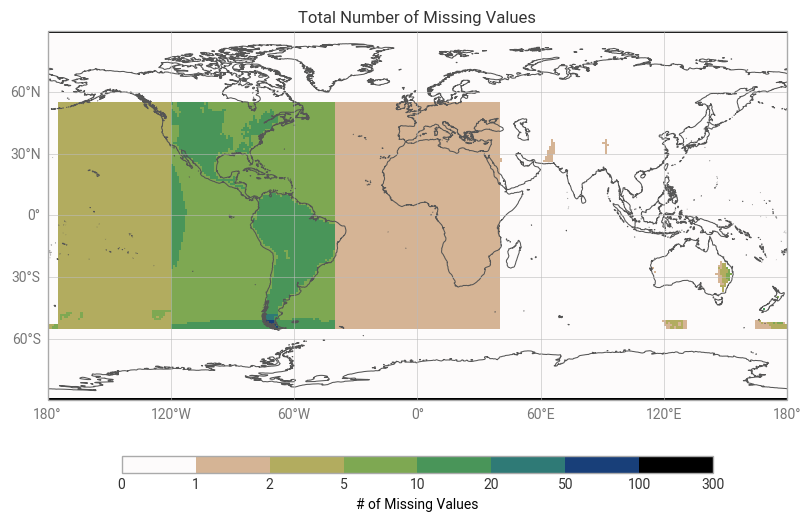

In [23]:
ds = xr.open_dataset(f"GIRAFE_{frequency}_missing.nc")
missing = ds['Missing_values']

style=ekp.styles.Style(
    colors="gist_earth_r",
    levels=[0,1,2,5,10,20,50,100,300],
    ticks=[0,1,2,5,10,20,50,100,300],
)

chart = ekp.Map()
# chart.contourf(ds[0],style=style)  
chart.pcolormesh(missing,style=style)

# Add a title with metadata formatting
chart.title("Total Number of Missing Values")

# Add map decorations
chart.coastlines()
# chart.borders()
chart.gridlines()

# Add a legend
chart.legend(label="# of Missing Values")
chart.show()

In [31]:
import numpy as np
import xarray as xr
import pandas as pd
import plotly.graph_objects as go


# ============================================================
# Configuration
# ============================================================

var = "precipitation"

locations = {
    "Amazon": (-60, -5),
    "Sahara": (10, 23),
    "UK": (-2, 54),
    "Alps": (10, 46)
}


# ============================================================
# Load data
# ============================================================

collection_dates = pd.date_range(
    product_parameters["collection_start"],
    product_parameters["collection_end"],
    freq="MS"
)

flist = [
    df.loc[
        df["file_date"] == collection_dates[i].strftime("%Y%m"),
        "file_path"
    ].iloc[0]
    for i in range(len(collection_dates))
]

ds = xr.open_mfdataset(
    flist,
    combine="nested",
    concat_dim="time"
)


# ============================================================
# Create figure
# ============================================================

fig = go.Figure()


for name, (lon, lat) in locations.items():

    # --------------------------------------------------------
    # Select nearest grid point
    # --------------------------------------------------------

    ts = ds[var].sel(
        lon=lon,
        lat=lat,
        method="nearest"
    )

    dates = pd.to_datetime(ts.time.values)
    values = ts.values.astype(float)

    # Actual grid point
    actual_lon = float(ts.lon.values)
    actual_lat = float(ts.lat.values)

    # --------------------------------------------------------
    # 1. Visible precipitation line
    # --------------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=dates,
            y=values,
            mode="lines",
            name=name,
            connectgaps=False,
            hoverinfo="skip"
        )
    )

    # --------------------------------------------------------
    # 2. Invisible hover trace
    # --------------------------------------------------------

    hover_text = []

    for date, value in zip(dates, values):

        if np.isnan(value):

            hover_text.append(
                f"<b>{name}</b><br>"
                f"Precipitation: Missing<br>"
                f"Grid point: "
                f"({actual_lon:.2f}°, {actual_lat:.2f}°)"
            )

        else:

            hover_text.append(
                f"<b>{name}</b><br>"
                f"Precipitation: {value:.3f}<br>"
                f"Grid point: "
                f"({actual_lon:.2f}°, {actual_lat:.2f}°)"
            )

    fig.add_trace(
    go.Scatter(
        x=dates,
        y=np.zeros(len(dates)),
        mode="markers",
        marker=dict(
            size=12,
            opacity=0
        ),
        customdata=np.column_stack([
            values
        ]),
        text=hover_text,
        name=name,
        hovertemplate="%{text}<extra></extra>",
        showlegend=False
    )
)


# ============================================================
# Layout
# ============================================================

fig.update_layout(
    title=dict(
        text="Precipitation Time Series at Selected Locations",
        x=0.5,
        xanchor="center"
    ),

    xaxis_title="Date",
    yaxis_title="Precipitation",

    template="plotly_white",

    hovermode="x unified",

    height=500,

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    margin=dict(
        l=70,
        r=40,
        t=100,
        b=60
    )
)

fig.show()

The global mean shows a jump in late 2023 that could be associated to the strong El Niño, since the same jump is not visible in the individual locations above.